In [1]:
import json
import pandas as pd
import numpy as np
import glob
import os

import warnings
warnings.filterwarnings(
    "ignore",
    message="Degrees of freedom <= 0 for slice",
    category=RuntimeWarning
)

In [3]:
# ----------------------------
# Define fallback PFTs (folder to try if original fails)
# Key = original PFT, value = folder name of fallback
# ----------------------------
fallback_pfts = {
    "tropical_broadleaved_evergreen_tree": "tropical_broadleaved_raingreen_tree"
}

folder = "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_08_run_for_10_locations/"
json_files = glob.glob(os.path.join(folder, "*", "loss_per_trial.json"))

# Map folder name -> JSON file path for quick access
json_map = {os.path.basename(os.path.dirname(f)): f for f in json_files}

results = []

# ----------------------------
# Loop over all original PFTs
# ----------------------------
for pft in json_map.keys():

    original_file = json_map[pft]

    # Try original PFT JSON first
    with open(original_file) as f:
        data = json.load(f)

    rows = []
    pft_key = pft.replace("_", " ")

    for trial_id, trial_data in data.items():
        params = trial_data["params"]
        gpp = trial_data["gpp_loss_water"].get(pft_key, np.nan)
        mort = trial_data["mort_loss_per_pft"].get(pft_key, np.nan)

        if gpp is not None and mort is not None:
            rows.append({
                "trial": int(trial_id),
                "pft": pft,  # always original PFT name
                "GPP_water": gpp,
                "MORT": mort,
                **params
            })

    # ----------------------------
    # If no trials, try fallback JSON (but still original PFT key)
    # ----------------------------
    if len(rows) == 0 and pft in fallback_pfts:
        fallback_folder = fallback_pfts[pft]
        if fallback_folder in json_map:
            fallback_file = json_map[fallback_folder]
            print(f"No valid trials for {pft}, trying fallback JSON {fallback_folder}.")

            with open(fallback_file) as f:
                fallback_data = json.load(f)

            for trial_id, trial_data in fallback_data.items():
                params = trial_data["params"]
                # still look for original PFT key
                gpp = trial_data["gpp_loss_water"].get(pft_key, np.nan)
                mort = trial_data["mort_loss_per_pft"].get(pft_key, np.nan)

                if gpp is not None and mort is not None:
                    rows.append({
                        "trial": int(trial_id),
                        "pft": pft,  # still original PFT name
                        "GPP_water": gpp,
                        "MORT": mort,
                        **params
                    })

    # Skip if still no trials
    if len(rows) == 0:
        print(f"No valid trials for {pft} or fallback, skipping.")
        continue

    df = pd.DataFrame(rows)
    df["distance"] = df["GPP_water"]**2 + df["MORT"]**2
    # Manual override for specific PFTs
    forced_trials = {
        "temperate_needleleaved_evergreen_tree": 35
    }

    if pft in forced_trials:
        forced_trial = forced_trials[pft]

        if forced_trial in df["trial"].values:
            best = df[df["trial"] == forced_trial].iloc[0]
            print(f"Using forced trial {forced_trial} for {pft}")
        else:
            print(f"Forced trial {forced_trial} not found for {pft}, using minimum distance")
            best = df.loc[df["distance"].idxmin()]
    else:
        best = df.loc[df["distance"].idxmin()]

    alpha_col = f"alpha_{pft}"
    beta_col = f"beta_{pft}"

    results.append({
        "pft": pft,
        "trial": best["trial"],
        "GPP_water": best["GPP_water"],
        "MORT": best["MORT"],
        "alpha": best.get(alpha_col, np.nan),
        "beta": best.get(beta_col, np.nan)
    })

# ----------------------------
# Combine all results
# ----------------------------
result_df = pd.DataFrame(results).sort_values("pft").reset_index(drop=True)
result_df

Using forced trial 35 for temperate_needleleaved_evergreen_tree


,pft,trial,GPP_water,MORT,alpha,beta
0,boreal_broadleaved_summergreen_tree,20,0.047514,0.217205,0.371489,1.535247
1,boreal_needleleaved_evergreen_tree,42,0.025620,0.236687,0.025814,3.533724
2,boreal_needleleaved_summergreen_tree,37,0.070890,0.295217,0.025994,24.583026
3,temperate_broadleaved_evergreen_tree,97,0.120996,0.135652,0.187226,8.386350
4,temperate_broadleaved_summergreen_tree,89,0.146439,0.231336,0.495985,17.755264
5,temperate_needleleaved_evergreen_tree,35,0.092207,0.247191,0.110851,22.102746
6,tropical_broadleaved_evergreen_tree,80,0.137194,0.180282,0.098918,0.926595
7,tropical_broadleaved_raingreen_tree,79,0.187101,0.233694,0.559405,1.464611


In [4]:
import os
import xarray as xr
import numpy as np
import pandas as pd

# -----------------------------
# Constants
# -----------------------------
START_YEAR = 2000
END_YEAR   = 2019

pfts = [
    "tropical broadleaved evergreen tree",
    "tropical broadleaved raingreen tree",
    "temperate needleleaved evergreen tree",
    "temperate broadleaved evergreen tree",
    "temperate broadleaved summergreen tree",
    "boreal needleleaved evergreen tree",
    "boreal broadleaved summergreen tree",
    "boreal needleleaved summergreen tree"
]

S_obs_mort = -0.46
intercept_mort = -1.96
S_obs_gpp_water = {0: 0.14, 1: 0.12, 2: 0.12, 3: 0.17,
                   4: 0.18, 5: 0.08, 6: 0.08, 7: 0.10}
intercept_gpp = {0: 0.02, 1: 0.03, 2: 0.02, 3: 0.04, 
                 4: 0.04, 5: 0.01, 6: 0.00, 7: 0.01}

baseline_root = "/projects/prjs2023/chapter3/lpjml_output/2026_01_20_run_for_every_location"

# -----------------------------
# Standardized anomalies function
# -----------------------------
def standardized_anomalies(data, start_year=START_YEAR, end_year=END_YEAR):
    data_ref = data.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    clim_mean = data_ref.groupby("time.month").mean("time")
    clim_std = data_ref.groupby("time.month").std("time")
    clim_std = clim_std.where(clim_std != 0)

    return xr.apply_ufunc(
        lambda x, m, s: (x - m) / s if s != 0 else np.nan,
        data.groupby("time.month"),
        clim_mean,
        clim_std,
        vectorize=True
    )

# -----------------------------
# Load global datasets
# -----------------------------
obs_spei = xr.open_dataset(
    "/projects/prjs2023/chapter3/SPEI/SPEI12_monthly_1901_2019_0_1_degree_2025_01_06_remapnn.nc"
)["SPEI"]

In [5]:
baseline_losses = {}

for pft_idx, pft in enumerate(pfts):

    gpp_all = []
    spei_all = []

    mort_all = []
    spei_all_y = []

    for patch in range(1, 11):

        base_out = os.path.join(
            "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations",
            pft.replace(" ", "_"),
            "baseline",
            f"patch_{patch}/output"
        )
        print(base_out)

        gpp_file  = os.path.join(base_out, "pft_gpp.nc")
        mort_file = os.path.join(base_out, "pft_mort.nc")
        fpc_file  = os.path.join(base_out, "fpc.nc")

        if not (os.path.exists(gpp_file) and os.path.exists(mort_file) and os.path.exists(fpc_file)):
            print(f"[WARN] missing {pft}, patch {patch}")
            continue

        # -------------------
        # load
        # -------------------
        gpp = xr.open_dataset(gpp_file)["GPP"].sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="MS").mean()

        mort = xr.open_dataset(mort_file)["mortality"].sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="YS").sum()

        fpc = xr.open_dataset(fpc_file)["FPC"][:, 1:].sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="MS").mean()
        
        fpc['pft'] = fpc.pft - 1  # adjust PFT index to match GPP/mortality

        fpc_safe = fpc.where(fpc > 1e-5)

        # -------------------
        # process GPP
        # -------------------
        gpp_per_fpc = gpp.isel(pft=pft_idx) / fpc_safe.isel(pft=pft_idx)
        gpp_std = standardized_anomalies(gpp_per_fpc)

        obs_spei_sub = obs_spei.sel(
            lat=slice(gpp.lat.min(), gpp.lat.max()),
            lon=slice(gpp.lon.min(), gpp.lon.max()),
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="MS").mean()

        spei = obs_spei_sub.values.flatten()
        gpp_vals = gpp_std.values.flatten()

        m = np.isfinite(gpp_vals) & np.isfinite(spei[:gpp_vals.size])

        gpp_all.append(gpp_vals[m])
        spei_all.append(spei[:gpp_vals.size][m])

        # -------------------
        # process mortality
        # -------------------
        mort_raw = mort.isel(pft=pft_idx).values.flatten()
        mort_raw = np.where(mort_raw > 0, mort_raw, np.nan)
        mort_vals = np.log10(mort_raw)
        spei_y = obs_spei_sub.resample(time="YS").mean().values.flatten()

        m2 = np.isfinite(mort_vals) & np.isfinite(spei_y)

        mort_all.append(mort_vals[m2])
        spei_all_y.append(spei_y[m2])

    # ======================================================
    # CONCATENATE ALL PATCHES → ONE FIT PER PFT
    # ======================================================

    if len(gpp_all) > 0:

        gpp_all = np.concatenate(gpp_all) if len(gpp_all) > 0 else np.array([])
        spei_all = np.concatenate(spei_all) if len(spei_all) > 0 else np.array([])
        
        valid = np.isfinite(gpp_all) & np.isfinite(spei_all)

        gpp_all = gpp_all[valid]
        spei_all = spei_all[valid]

        if gpp_all.size < 10:
            gpp_loss = None
        else:
            S_fit, b_fit = np.polyfit(spei_all, gpp_all, 1)
        
        y_model = S_fit * spei_all + b_fit
        y_obs = S_obs_gpp_water[pft_idx] * spei_all + intercept_gpp[pft_idx]

        gpp_loss = np.sqrt(np.mean((y_model - y_obs) ** 2))

    else:
        gpp_loss = None

    if len(mort_all) > 0:

        mort_all = np.concatenate(mort_all) if len(mort_all) > 0 else np.array([])
        spei_all_y = np.concatenate(spei_all_y) if len(spei_all_y) > 0 else np.array([])

        valid = np.isfinite(mort_all) & np.isfinite(spei_all_y)

        mort_all = mort_all[valid]
        spei_all_y = spei_all_y[valid]

        if mort_all.size < 10:
            mort_loss = None
        else:
            S_fit, b_fit = np.polyfit(spei_all_y, mort_all, 1)

        y_model = S_fit * spei_all_y + b_fit
        y_obs = S_obs_mort * spei_all_y + intercept_mort

        mort_loss = np.sqrt(np.mean((y_model - y_obs) ** 2))

    else:
        mort_loss = None

    baseline_losses[pft] = {
        "GPP_loss_baseline": gpp_loss,
        "Mort_loss_baseline": mort_loss
    }

baseline_df = pd.DataFrame(baseline_losses).T.reset_index().rename(columns={"index": "pft"})
baseline_df

/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline/patch_1/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline/patch_2/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline/patch_3/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline/patch_4/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline/patch_5/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline/patch_6/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline/patch_7/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locati

,pft,GPP_loss_baseline,Mort_loss_baseline
0,tropical broadleaved evergreen tree,0.040426,0.333412
1,tropical broadleaved raingreen tree,0.247038,0.273793
2,temperate needleleaved evergreen tree,0.087119,0.365285
3,temperate broadleaved evergreen tree,0.203390,0.390516
4,temperate broadleaved summergreen tree,0.140473,0.363855
5,boreal needleleaved evergreen tree,0.007387,0.222690
6,boreal broadleaved summergreen tree,0.103096,0.326752
7,boreal needleleaved summergreen tree,0.092536,0.328164


In [6]:
monthly_mort_losses = {}

for pft_idx, pft in enumerate(pfts):

    gpp_all = []
    spei_all = []

    mort_all = []
    spei_all_y = []

    for patch in range(1, 11):

        base_out = os.path.join(
            "/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations",
            pft.replace(" ", "_"),
            "baseline_MM",
            f"patch_{patch}/output"
        )
        print(base_out)

        gpp_file  = os.path.join(base_out, "pft_gpp.nc")
        mort_file = os.path.join(base_out, "pft_mort.nc")
        fpc_file  = os.path.join(base_out, "fpc.nc")

        if not (os.path.exists(gpp_file) and os.path.exists(mort_file) and os.path.exists(fpc_file)):
            print(f"[WARN] missing {pft}, patch {patch}")
            continue

        # -------------------
        # load
        # -------------------
        gpp = xr.open_dataset(gpp_file)["GPP"].sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="MS").mean()

        mort = xr.open_dataset(mort_file)["mortality"].sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="YS").sum()

        fpc = xr.open_dataset(fpc_file)["FPC"][:, 1:].sel(
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="MS").mean()
        
        fpc['pft'] = fpc.pft - 1  # adjust PFT index to match GPP/mortality

        fpc_safe = fpc.where(fpc > 1e-5)

        # -------------------
        # process GPP
        # -------------------
        gpp_per_fpc = gpp.isel(pft=pft_idx) / fpc_safe.isel(pft=pft_idx)
        gpp_std = standardized_anomalies(gpp_per_fpc)

        obs_spei_sub = obs_spei.sel(
            lat=slice(gpp.lat.min(), gpp.lat.max()),
            lon=slice(gpp.lon.min(), gpp.lon.max()),
            time=slice(f"{START_YEAR}", f"{END_YEAR}")
        ).resample(time="MS").mean()

        spei = obs_spei_sub.values.flatten()
        gpp_vals = gpp_std.values.flatten()

        m = np.isfinite(gpp_vals) & np.isfinite(spei[:gpp_vals.size])

        gpp_all.append(gpp_vals[m])
        spei_all.append(spei[:gpp_vals.size][m])

        # -------------------
        # process mortality
        # -------------------
        mort_raw = mort.isel(pft=pft_idx).values.flatten()
        mort_raw = np.where(mort_raw > 0, mort_raw, np.nan)
        mort_vals = np.log10(mort_raw)
        spei_y = obs_spei_sub.resample(time="YS").mean().values.flatten()

        m2 = np.isfinite(mort_vals) & np.isfinite(spei_y)

        mort_all.append(mort_vals[m2])
        spei_all_y.append(spei_y[m2])

    # ======================================================
    # CONCATENATE ALL PATCHES → ONE FIT PER PFT
    # ======================================================

    if len(gpp_all) > 0:

        gpp_all = np.concatenate(gpp_all) if len(gpp_all) > 0 else np.array([])
        spei_all = np.concatenate(spei_all) if len(spei_all) > 0 else np.array([])
        
        valid = np.isfinite(gpp_all) & np.isfinite(spei_all)

        gpp_all = gpp_all[valid]
        spei_all = spei_all[valid]

        if gpp_all.size < 10:
            gpp_loss = None
        else:
            S_fit, b_fit = np.polyfit(spei_all, gpp_all, 1)
        
        y_model = S_fit * spei_all + b_fit
        y_obs = S_obs_gpp_water[pft_idx] * spei_all + intercept_gpp[pft_idx]

        gpp_loss = np.sqrt(np.mean((y_model - y_obs) ** 2))

    else:
        gpp_loss = None

    if len(mort_all) > 0:

        mort_all = np.concatenate(mort_all) if len(mort_all) > 0 else np.array([])
        spei_all_y = np.concatenate(spei_all_y) if len(spei_all_y) > 0 else np.array([])

        valid = np.isfinite(mort_all) & np.isfinite(spei_all_y)

        mort_all = mort_all[valid]
        spei_all_y = spei_all_y[valid]

        if mort_all.size < 10:
            mort_loss = None
        else:
            S_fit, b_fit = np.polyfit(spei_all_y, mort_all, 1)

        y_model = S_fit * spei_all_y + b_fit
        y_obs = S_obs_mort * spei_all_y + intercept_mort

        mort_loss = np.sqrt(np.mean((y_model - y_obs) ** 2))

    else:
        mort_loss = None

    monthly_mort_losses[pft] = {
        "GPP_loss_monthlymort": gpp_loss,
        "Mort_loss_monthlymort": mort_loss
    }

monthlymort_df = pd.DataFrame(monthly_mort_losses).T.reset_index().rename(columns={"index": "pft"})
monthlymort_df

/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM/patch_1/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM/patch_2/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM/patch_3/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM/patch_4/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM/patch_5/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM/patch_6/output
/projects/prjs2023/chapter3/lpjml_output/2026_04_08_run_for_10_locations/tropical_broadleaved_evergreen_tree/baseline_MM/patch_7/output
/projects/prjs2023/chapter3/lpjml_output/2026_04

,pft,GPP_loss_monthlymort,Mort_loss_monthlymort
0,tropical broadleaved evergreen tree,0.045446,0.352254
1,tropical broadleaved raingreen tree,0.253023,0.262374
2,temperate needleleaved evergreen tree,0.090493,0.384741
3,temperate broadleaved evergreen tree,0.211675,0.371387
4,temperate broadleaved summergreen tree,0.143556,0.356380
5,boreal needleleaved evergreen tree,0.007394,0.282766
6,boreal broadleaved summergreen tree,0.100953,0.364782
7,boreal needleleaved summergreen tree,0.092146,0.314468


In [7]:
# Standardize PFT names: replace spaces with underscores in baseline_df
baseline_df = baseline_df.copy()
baseline_df["pft"] = baseline_df["pft"].str.replace(" ", "_")

# Merge baseline and calibrated results
combined_df = pd.merge(
    baseline_df,
    result_df,
    on="pft",
    how="left"  # keep all baseline PFTs
)

# Compute improvement (reduction in loss)
combined_df["GPP_loss_reduction"] = combined_df["GPP_loss_baseline"] - combined_df["GPP_water"]
combined_df["Mort_loss_reduction"] = combined_df["Mort_loss_baseline"] - combined_df["MORT"]

# Reorder columns for clarity
combined_df = combined_df[
    ["pft", "trial", "GPP_loss_baseline", "GPP_water", "GPP_loss_reduction",
     "Mort_loss_baseline", "MORT", "Mort_loss_reduction",
     "alpha", "beta"]
]

combined_df

,pft,trial,GPP_loss_baseline,GPP_water,GPP_loss_reduction,Mort_loss_baseline,MORT,Mort_loss_reduction,alpha,beta
0,tropical_broadleaved_evergreen_tree,80,0.040426,0.137194,-0.096768,0.333412,0.180282,0.153129,0.098918,0.926595
1,tropical_broadleaved_raingreen_tree,79,0.247038,0.187101,0.059937,0.273793,0.233694,0.040099,0.559405,1.464611
2,temperate_needleleaved_evergreen_tree,35,0.087119,0.092207,-0.005088,0.365285,0.247191,0.118094,0.110851,22.102746
3,temperate_broadleaved_evergreen_tree,97,0.203390,0.120996,0.082394,0.390516,0.135652,0.254864,0.187226,8.386350
4,temperate_broadleaved_summergreen_tree,89,0.140473,0.146439,-0.005965,0.363855,0.231336,0.132518,0.495985,17.755264
5,boreal_needleleaved_evergreen_tree,42,0.007387,0.025620,-0.018232,0.222690,0.236687,-0.013998,0.025814,3.533724
6,boreal_broadleaved_summergreen_tree,20,0.103096,0.047514,0.055582,0.326752,0.217205,0.109547,0.371489,1.535247
7,boreal_needleleaved_summergreen_tree,37,0.092536,0.070890,0.021646,0.328164,0.295217,0.032947,0.025994,24.583026


In [8]:
# -----------------------------
# Standardize PFT names
# -----------------------------
monthlymort_df = monthlymort_df.copy()
monthlymort_df["pft"] = monthlymort_df["pft"].str.replace(" ", "_")

# -----------------------------
# Merge monthlymort into combined_df
# -----------------------------
combined_df = pd.merge(
    combined_df,
    monthlymort_df,
    on="pft",
    how="left"
)

# -----------------------------
# Optional: compute improvements vs monthlymort
# -----------------------------
combined_df["GPP_loss_reduction_monthlymort"] = (
    combined_df["GPP_loss_monthlymort"] - combined_df["GPP_water"]
)

combined_df["Mort_loss_reduction_monthlymort"] = (
    combined_df["Mort_loss_monthlymort"] - combined_df["MORT"]
)

# -----------------------------
# Reorder columns (optional)
# -----------------------------
combined_df = combined_df[
    [
        "pft", "trial",
        
        "GPP_loss_baseline", "GPP_loss_monthlymort", "GPP_water",
        "GPP_loss_reduction", "GPP_loss_reduction_monthlymort",
        
        "Mort_loss_baseline", "Mort_loss_monthlymort", "MORT",
        "Mort_loss_reduction", "Mort_loss_reduction_monthlymort",
        
        "alpha", "beta"
    ]
]

combined_df

,pft,trial,GPP_loss_baseline,GPP_loss_monthlymort,GPP_water,GPP_loss_reduction,GPP_loss_reduction_monthlymort,Mort_loss_baseline,Mort_loss_monthlymort,MORT,Mort_loss_reduction,Mort_loss_reduction_monthlymort,alpha,beta
0,tropical_broadleaved_evergreen_tree,80,0.040426,0.045446,0.137194,-0.096768,-0.091748,0.333412,0.352254,0.180282,0.153129,0.171971,0.098918,0.926595
1,tropical_broadleaved_raingreen_tree,79,0.247038,0.253023,0.187101,0.059937,0.065921,0.273793,0.262374,0.233694,0.040099,0.028680,0.559405,1.464611
2,temperate_needleleaved_evergreen_tree,35,0.087119,0.090493,0.092207,-0.005088,-0.001715,0.365285,0.384741,0.247191,0.118094,0.137551,0.110851,22.102746
3,temperate_broadleaved_evergreen_tree,97,0.203390,0.211675,0.120996,0.082394,0.090679,0.390516,0.371387,0.135652,0.254864,0.235735,0.187226,8.386350
4,temperate_broadleaved_summergreen_tree,89,0.140473,0.143556,0.146439,-0.005965,-0.002883,0.363855,0.356380,0.231336,0.132518,0.125044,0.495985,17.755264
5,boreal_needleleaved_evergreen_tree,42,0.007387,0.007394,0.025620,-0.018232,-0.018226,0.222690,0.282766,0.236687,-0.013998,0.046078,0.025814,3.533724
6,boreal_broadleaved_summergreen_tree,20,0.103096,0.100953,0.047514,0.055582,0.053438,0.326752,0.364782,0.217205,0.109547,0.147577,0.371489,1.535247
7,boreal_needleleaved_summergreen_tree,37,0.092536,0.092146,0.070890,0.021646,0.021256,0.328164,0.314468,0.295217,0.032947,0.019251,0.025994,24.583026


In [ ]:
# -----------------------------
# Standardize PFT names
# -----------------------------
monthlymort_df = monthlymort_df.copy()
monthlymort_df["pft"] = monthlymort_df["pft"].str.replace(" ", "_")

# -----------------------------
# Merge monthlymort into combined_df
# -----------------------------
combined_df = pd.merge(
    combined_df,
    monthlymort_df,
    on="pft",
    how="left"
)

# -----------------------------
# Optional: compute improvements vs monthlymort
# -----------------------------
combined_df["GPP_loss_reduction_monthlymort"] = (
    combined_df["GPP_loss_monthlymort"] - combined_df["GPP_water"]
)

combined_df["Mort_loss_reduction_monthlymort"] = (
    combined_df["Mort_loss_monthlymort"] - combined_df["MORT"]
)

# -----------------------------
# Reorder columns (optional)
# -----------------------------
combined_df = combined_df[
    [
        "pft", "trial",
        
        "GPP_loss_baseline", "GPP_loss_monthlymort", "GPP_water",
        "GPP_loss_reduction", "GPP_loss_reduction_monthlymort",
        
        "Mort_loss_baseline", "Mort_loss_monthlymort", "MORT",
        "Mort_loss_reduction", "Mort_loss_reduction_monthlymort",
        
        "alpha", "beta"
    ]
]

combined_df

,pft,trial,GPP_loss_baseline,GPP_loss_monthlymort,GPP_water,GPP_loss_reduction,GPP_loss_reduction_monthlymort,Mort_loss_baseline,Mort_loss_monthlymort,MORT,Mort_loss_reduction,Mort_loss_reduction_monthlymort,alpha,beta
0,tropical_broadleaved_evergreen_tree,80,0.040426,0.045446,0.137194,-0.096768,-0.091748,0.333412,0.352254,0.180282,0.153129,0.171971,0.098918,0.926595
1,tropical_broadleaved_raingreen_tree,79,0.247038,0.253023,0.187101,0.059937,0.065921,0.273793,0.262374,0.233694,0.040099,0.028680,0.559405,1.464611
2,temperate_needleleaved_evergreen_tree,36,0.087119,0.090493,0.159297,-0.072178,-0.068804,0.365285,0.384741,0.204383,0.160903,0.180359,0.233482,22.782286
3,temperate_broadleaved_evergreen_tree,97,0.203390,0.211675,0.120996,0.082394,0.090679,0.390516,0.371387,0.135652,0.254864,0.235735,0.187226,8.386350
4,temperate_broadleaved_summergreen_tree,89,0.140473,0.143556,0.146439,-0.005965,-0.002883,0.363855,0.356380,0.231336,0.132518,0.125044,0.495985,17.755264
5,boreal_needleleaved_evergreen_tree,42,0.007387,0.007394,0.025620,-0.018232,-0.018226,0.222690,0.282766,0.236687,-0.013998,0.046078,0.025814,3.533724
6,boreal_broadleaved_summergreen_tree,20,0.103096,0.100953,0.047514,0.055582,0.053438,0.326752,0.364782,0.217205,0.109547,0.147577,0.371489,1.535247
7,boreal_needleleaved_summergreen_tree,37,0.092536,0.092146,0.070890,0.021646,0.021256,0.328164,0.314468,0.295217,0.032947,0.019251,0.025994,24.583026


In [9]:
pft_map = {
    "tropical_broadleaved_evergreen_tree": "Trop BE",
    "tropical_broadleaved_raingreen_tree": "Trop BR",
    "temperate_needleleaved_evergreen_tree": "Temp NE",
    "temperate_broadleaved_evergreen_tree": "Temp BE",
    "temperate_broadleaved_summergreen_tree": "Temp BS",
    "boreal_needleleaved_evergreen_tree": "Bor NE",
    "boreal_broadleaved_summergreen_tree": "Bor BS",
    "boreal_needleleaved_summergreen_tree": "Bor NS",
}

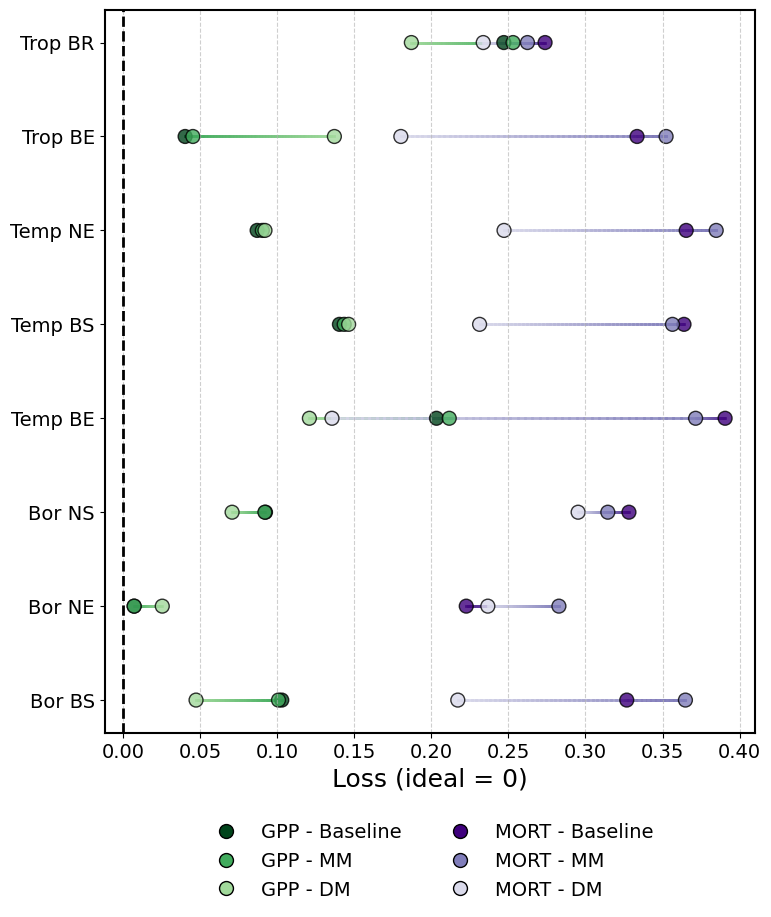

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    "font.size": 16,        # base font
    "axes.labelsize": 18,   # axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15
})

# ----------------------------
# Function to draw gradient line
# ----------------------------
def draw_gradient_line(x0, x1, y, color_start, color_end, n=50):
    xs = np.linspace(x0, x1, n)
    
    # Convert colors to RGB
    c0 = np.array(mcolors.to_rgb(color_start))
    c1 = np.array(mcolors.to_rgb(color_end))
    
    for i in range(n - 1):
        t = i / (n - 1)
        color = c0 * (1 - t) + c1 * t  # interpolate color
        
        plt.plot(
            xs[i:i+2],
            [y, y],
            color=color,
            linewidth=2,
            alpha=0.9,
            zorder=1
        )

# ----------------------------
# Build plotting data including monthlymort
# ----------------------------
gpp_df_plot = pd.concat([
    pd.DataFrame({
        "pft": combined_df["pft"],
        "Loss": combined_df["GPP_loss_baseline"],
        "Type": "Baseline"
    }),
    pd.DataFrame({
        "pft": combined_df["pft"],
        "Loss": combined_df["GPP_loss_monthlymort"],
        "Type": "MonthlyMort"
    }),
    pd.DataFrame({
        "pft": combined_df["pft"],
        "Loss": combined_df["GPP_water"],
        "Type": "Calibrated"
    })
])
gpp_df_plot["Loss_type"] = "GPP"


mort_df_plot = pd.concat([
    pd.DataFrame({
        "pft": combined_df["pft"],
        "Loss": combined_df["Mort_loss_baseline"],
        "Type": "Baseline"
    }),
    pd.DataFrame({
        "pft": combined_df["pft"],
        "Loss": combined_df["Mort_loss_monthlymort"],
        "Type": "MonthlyMort"
    }),
    pd.DataFrame({
        "pft": combined_df["pft"],
        "Loss": combined_df["MORT"],
        "Type": "Calibrated"
    })
])
mort_df_plot["Loss_type"] = "MORT"

plot_df = pd.concat([gpp_df_plot, mort_df_plot], ignore_index=True)

plot_df["Type"] = pd.Categorical(
    plot_df["Type"],
    categories=["Baseline", "MonthlyMort", "Calibrated"],
    ordered=True
)

plot_df = plot_df.sort_values(["pft", "Loss_type", "Type"])
plot_df["pft_short"] = plot_df["pft"].map(pft_map)

# ----------------------------
# Define sizes
# ----------------------------
size_map = {
    "Baseline": 100,
    "MonthlyMort": 100,
    "Calibrated": 100
}
sizes = plot_df["Type"].map(size_map).to_numpy(dtype=float)

# ----------------------------
# Determine x-axis range
# ----------------------------
x_min, x_max = plot_df["Loss"].min(), plot_df["Loss"].max()
x_padding = (x_max - x_min) * 0.05
x_range = (x_min - x_padding, x_max + x_padding)


def get_color(row):
    if row["Loss_type"] == "GPP":
        if row["Type"] == "Baseline":
            return "#00441b"   # dark green
        elif row["Type"] == "MonthlyMort":
            return "#41ab5d"   # medium green
        elif row["Type"] == "Calibrated":
            return "#a1d99b"   # light green

    elif row["Loss_type"] == "MORT":
        if row["Type"] == "Baseline":
            return "#3f007d"   # dark purple
        elif row["Type"] == "MonthlyMort":
            return "#807dba"   # medium purple
        elif row["Type"] == "Calibrated":
            return "#dadaeb"   # light purple
        
plot_df["color"] = plot_df.apply(get_color, axis=1)
        
# Order of types
type_order = ["Baseline", "MonthlyMort", "Calibrated"]
plt.figure(figsize=(8, 10))

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

for pft in plot_df["pft_short"].unique():

    subset = plot_df[plot_df["pft_short"] == pft]

    # --- GPP ---
    gpp_points = subset[subset["Loss_type"] == "GPP"]
    if len(gpp_points) == 3:
        gpp_points = gpp_points.set_index("Type").loc[type_order].reset_index()
        x_vals = gpp_points["Loss"].values

        # baseline → monthly
        draw_gradient_line(
            x_vals[0], x_vals[1], pft,
            color_start="#006d2c",
            color_end="#41ab5d"
        )

        # monthly → calibrated
        draw_gradient_line(
            x_vals[1], x_vals[2], pft,
            color_start="#41ab5d",
            color_end="#a1d99b"
        )

    # --- MORT ---
    mort_points = subset[subset["Loss_type"] == "MORT"]
    if len(mort_points) == 3:
        mort_points = mort_points.set_index("Type").loc[type_order].reset_index()
        x_vals = mort_points["Loss"].values

        draw_gradient_line(
            x_vals[0], x_vals[1], pft,
            color_start="#54278f",
            color_end="#807dba"
        )

        draw_gradient_line(
            x_vals[1], x_vals[2], pft,
            color_start="#807dba",
            color_end="#dadaeb"
        )
        
        
plt.scatter(
    x=plot_df["Loss"],
    y=plot_df["pft_short"],
    s=sizes,
    c=plot_df["color"],
    edgecolors="k",
    alpha=0.8
)

# Vertical line at 0
plt.axvline(0, color="black", linestyle="--", linewidth=2)

plt.xlabel("Loss (ideal = 0)")
# plt.ylabel("PFT")
# plt.title("GPP and MORT Loss per PFT (Baseline → MonthlyMort → Calibrated)")
plt.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.xlim(x_range)
        
legend_handles = [
    # GPP
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#00441b", markeredgecolor='k', markersize=10, label="GPP - Baseline"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#41ab5d", markeredgecolor='k', markersize=10, label="GPP - MM"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#a1d99b", markeredgecolor='k', markersize=10, label="GPP - DM"),

    # MORT
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#3f007d", markeredgecolor='k', markersize=10, label="MORT - Baseline"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#807dba", markeredgecolor='k', markersize=10, label="MORT - MM"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#dadaeb", markeredgecolor='k', markersize=10, label="MORT - DM"),
]

plt.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    "/home/druijsch/scripts/2026_06_01_loss_figure/2026_06_01_loss_dots.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
